In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv('/content/placementdata.csv')

In [19]:
categorical_cols = ['ExtracurricularActivities', 'PlacementTraining', 'PlacementStatus']
for col in categorical_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'Placed': 1, 'NotPlaced': 0})

In [20]:
X = df.drop(['StudentID', 'PlacementStatus'], axis=1)
y = df['PlacementStatus']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

--- Random Forest Performance ---
Accuracy: 0.78

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.82      1172
           1       0.75      0.71      0.73       828

    accuracy                           0.78      2000
   macro avg       0.78      0.77      0.77      2000
weighted avg       0.78      0.78      0.78      2000



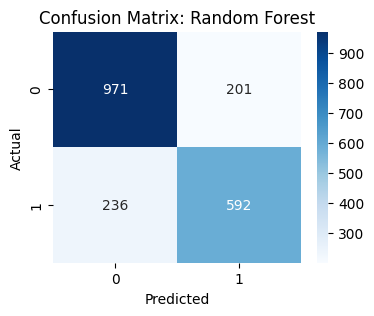

------------------------------


In [23]:
y_pred = rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("--- Random Forest Performance ---")
print(f"Accuracy: {acc:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("-" * 30)

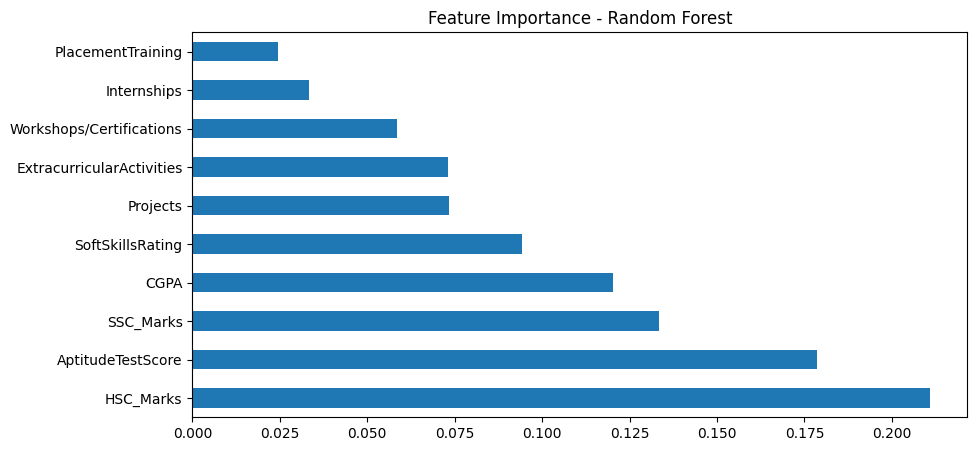

In [24]:
plt.figure(figsize=(10, 5))
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Feature Importance - Random Forest")
plt.show()

In [25]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:04:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

--- XG Boost Performance ---
Accuracy: 0.78

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.82      0.81      1172
           1       0.74      0.72      0.73       828

    accuracy                           0.78      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.78      0.78      0.78      2000



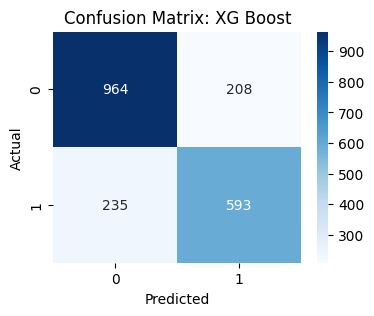

------------------------------


In [26]:

y_pred = xgb_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("--- XG Boost Performance ---")
print(f"Accuracy: {acc:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: XG Boost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("-" * 30)

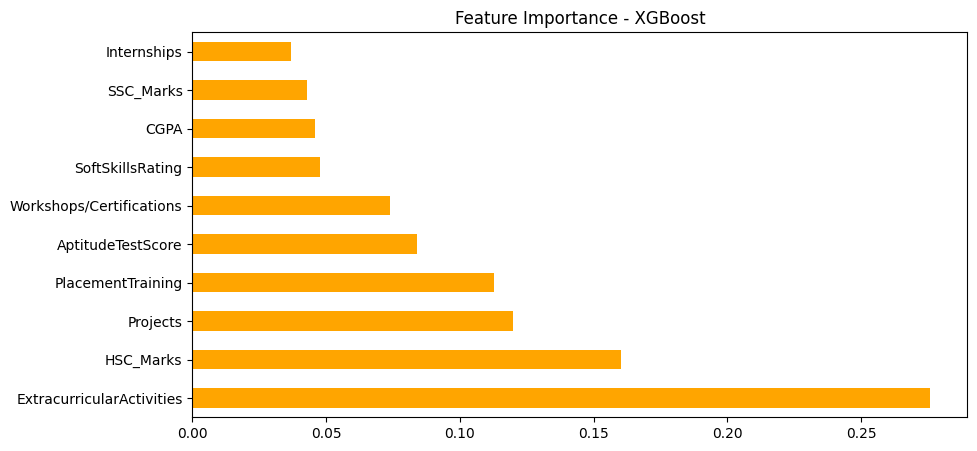

In [27]:
plt.figure(figsize=(10, 5))
xgb_feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
xgb_feat_importances.nlargest(10).plot(kind='barh', color='orange')
plt.title("Feature Importance - XGBoost")
plt.show()